# Advanced Mutual Fund Analytics

This notebook performs:
- Historical VaR & CVaR
- Rolling Sharpe Ratio
- Investor Cohort Analysis
- SIP Continuity Analysis
- Fund Recommendation System
- Sector HHI Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
DATA = Path("../data/processed")
RAW = Path("../data/raw")
REPORT = Path("../reports")

REPORT.mkdir(parents=True, exist_ok=True)

In [3]:
returns = pd.read_csv(DATA / "nav_daily_returns.csv")

In [4]:
returns.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [5]:
returns.columns

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='object')

In [6]:
# Remove missing daily returns
returns_clean = returns.dropna(subset=["daily_return"])

# Calculate VaR and CVaR for each scheme
var_cvar = []

for scheme, group in returns_clean.groupby("amfi_code"):

    # Historical VaR (95%)
    var95 = group["daily_return"].quantile(0.05)

    # CVaR
    cvar95 = group.loc[
        group["daily_return"] <= var95,
        "daily_return"
    ].mean()

    var_cvar.append({
        "amfi_code": scheme,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

var_cvar = pd.DataFrame(var_cvar)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [7]:
var_cvar.to_csv(
    REPORT / "var_cvar_report.csv",
    index=False
)

print("Report saved successfully!")

Report saved successfully!


In [8]:
var_cvar.describe()

,amfi_code,VaR_95,CVaR_95
count,40.000000,40.000000,40.000000
mean,120247.000000,-0.014711,-0.018580
std,14534.998667,0.006821,0.008476
min,100016.000000,-0.026859,-0.032459
25%,118632.750000,-0.018394,-0.023133
50%,119551.500000,-0.014376,-0.018185
75%,120842.250000,-0.013247,-0.016572
max,149324.000000,-0.000222,-0.000373


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
returns["date"] = pd.to_datetime(returns["date"])

returns = returns.sort_values(["amfi_code", "date"])

returns.head()


,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [11]:
returns["rolling_mean"] = (
    returns.groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).mean())
)

returns["rolling_std"] = (
    returns.groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).std())
)

returns["rolling_sharpe"] = (
    returns["rolling_mean"] /
    returns["rolling_std"]
) * np.sqrt(252)

returns.head()

,amfi_code,date,nav,daily_return,rolling_mean,rolling_std,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN,NaN,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN,NaN,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN,NaN,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN,NaN,NaN


In [12]:
returns["rolling_mean"] = (
    returns.groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).mean())
)

returns["rolling_std"] = (
    returns.groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).std())
)

returns["rolling_sharpe"] = (
    returns["rolling_mean"] /
    returns["rolling_std"]
) * np.sqrt(252)

returns.head()

,amfi_code,date,nav,daily_return,rolling_mean,rolling_std,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN,NaN,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN,NaN,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN,NaN,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN,NaN,NaN


In [13]:
top5 = returns["amfi_code"].drop_duplicates().head(5)

top5

0       100016
1150    100025
2300    100033
3450    101206
4600    101207
Name: amfi_code, dtype: int64

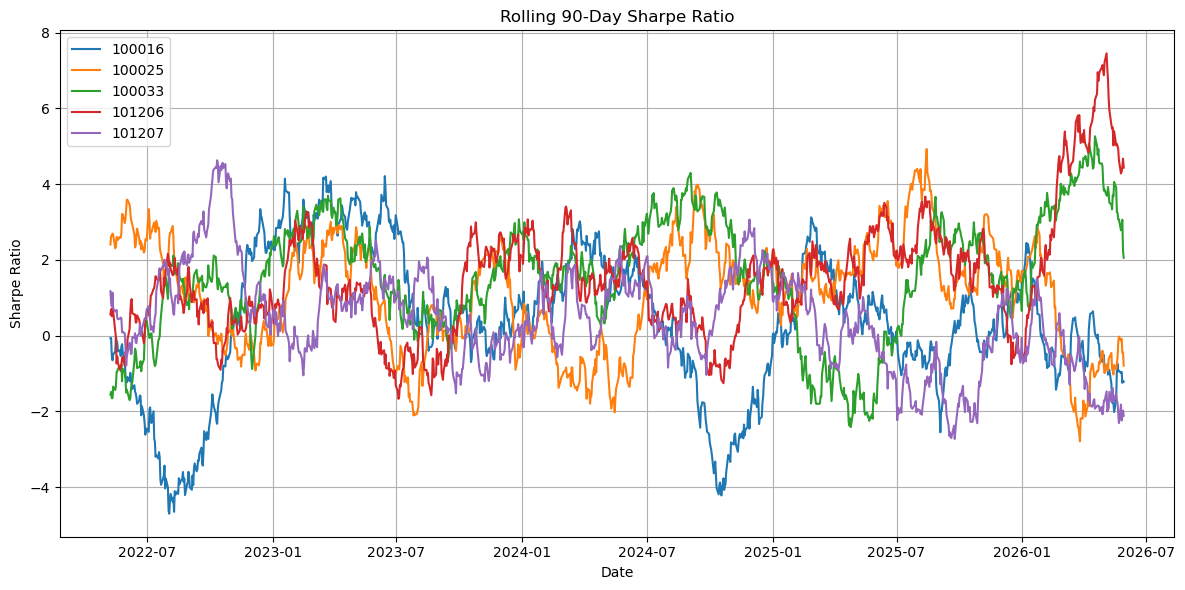

In [14]:
plt.figure(figsize=(12,6))

for fund in top5:
    temp = returns[returns["amfi_code"] == fund]
    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.tight_layout()

In [15]:
from pathlib import Path

output_dir = Path("reports/charts")
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_dir / "rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Chart saved successfully!")

Chart saved successfully!


In [16]:
transactions = pd.read_csv("data/raw/08_investor_transactions.csv")

transactions.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/08_investor_transactions.csv'

In [17]:
import os

print(os.getcwd())

/Users/krithikmenon/Desktop/blue stock mutual fund /notebooks


In [18]:
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [19]:
import os

print(os.listdir(".."))


['data_dictionary.md', 'mutual fund dashboard .png', '.DS_Store', 'requirements.txt', 'README.md', 'dashboard', 'reports ', '.gitignore', '.venv', 'scripts', 'mutual fund industry dashboard .twb', '.git', '.~mutual fund industry dashboard __97694.twbr', 'data', 'notebooks', 'reports', 'sql']


In [20]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

In [21]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [22]:
transactions["cohort_year"] = (
    transactions.groupby("investor_id")["transaction_date"]
    .transform("min")
    .dt.year
)

transactions.head()


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [23]:
cohort = (
    transactions
    .groupby("cohort_year")
    .agg(
        avg_investment=("amount_inr", "mean"),
        total_investment=("amount_inr", "sum"),
        investors=("investor_id", "nunique")
    )
)

cohort

,avg_investment,total_investment,investors
cohort_year,,,
2024,107422.541832,3491125187,4803
2025,109158.577061,30455243,197


In [24]:
cohort.to_csv(
    "reports/cohort_analysis.csv"
)

print("Cohort report saved!")

Cohort report saved!


In [25]:
sip = transactions[transactions["transaction_type"] == "SIP"].copy()

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [26]:
sip.groupby("investor_id").size().describe()


count    4762.000000
mean        4.140277
std         2.315046
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max        12.000000
dtype: float64

In [27]:
sip_counts = sip.groupby("investor_id").size()

eligible_investors = sip_counts[sip_counts >= 6].index

sip_eligible = sip[sip["investor_id"].isin(eligible_investors)].copy()

sip_eligible.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024
8,INV003670,2024-01-01,119120,SIP,10672,Punjab,Chandigarh,T30,36-45,Male,38.4,Net Banking,Verified,2024
11,INV001023,2024-01-01,118636,SIP,4865,Gujarat,Ahmedabad,T30,36-45,Male,27.1,Net Banking,Verified,2024


In [28]:
sip_eligible = sip_eligible.sort_values(
    ["investor_id", "transaction_date"]
)

sip_eligible["gap_days"] = (
    sip_eligible
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_eligible.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0
12003,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,59.0
28749,INV000004,2025-03-29,149324,SIP,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,265.0
31897,INV000004,2025-05-17,119599,SIP,2110,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,49.0
9329,INV000008,2024-05-27,101206,SIP,8061,Punjab,Amritsar,B30,26-35,Female,18.6,Cheque,Verified,2024,NaN
11113,INV000008,2024-06-23,102887,SIP,55850,Punjab,Amritsar,B30,26-35,Female,18.6,Net Banking,Verified,2024,27.0
21549,INV000008,2024-12-05,100025,SIP,425,Punjab,Amritsar,B30,26-35,Female,18.6,UPI,Verified,2024,165.0
24389,INV000008,2025-01-18,119552,SIP,458,Punjab,Amritsar,B30,26-35,Female,18.6,Cheque,Verified,2024,44.0


In [29]:
sip_gap = (
    sip_eligible
    .groupby("investor_id")
    .agg(avg_gap_days=("gap_days", "mean"))
)

sip_gap.head()

,avg_gap_days
investor_id,
INV000004,85.400000
INV000008,70.400000
INV000010,64.800000
INV000011,40.166667
INV000012,57.000000


In [30]:
sip_gap["status"] = sip_gap["avg_gap_days"].apply(
    lambda x: "At-Risk" if x > 35 else "Active"
)

sip_gap.head()


,avg_gap_days,status
investor_id,,
INV000004,85.400000,At-Risk
INV000008,70.400000,At-Risk
INV000010,64.800000,At-Risk
INV000011,40.166667,At-Risk
INV000012,57.000000,At-Risk


In [31]:
sip_gap.to_csv("reports/sip_continuity_report.csv")

print("SIP continuity report saved successfully!")


SIP continuity report saved successfully!


In [33]:
performance = pd.read_csv("../data/processed/clean_performance.csv")

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [34]:
import os
print(os.getcwd())

/Users/krithikmenon/Desktop/blue stock mutual fund /notebooks


In [35]:
performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [36]:
risk = "Moderate"      # Change to Low, Moderate, or High

recommendation = (
    performance[
        performance["risk_grade"].str.lower() == risk.lower()
    ]
    .sort_values("sharpe_ratio", ascending=False)
    [["scheme_name", "risk_grade", "sharpe_ratio"]]
    .head(3)
)

recommendation

,scheme_name,risk_grade,sharpe_ratio
5,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03


In [37]:
recommendation.to_csv(
    "reports/fund_recommendation.csv",
    index=False
)

print("Recommendation report saved!")

Recommendation report saved!


In [38]:
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [39]:
holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [40]:
# Convert weight percentage to decimal
holdings["weight"] = holdings["weight_pct"] / 100

# Calculate HHI for each fund
hhi = (
    holdings
    .groupby("amfi_code")
    .apply(lambda x: (x["weight"] ** 2).sum())
    .reset_index(name="HHI")
)

hhi.head()

/var/folders/zy/pr4n2x050nj6mt4x2h84438r0000gn/T/ipykernel_83878/1616011542.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["weight"] ** 2).sum())


,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [41]:
hhi.to_csv("reports/hhi_report.csv", index=False)

print("HHI report saved successfully!")

HHI report saved successfully!


# Advanced Insights

### 1. Historical VaR & CVaR
Funds with larger negative VaR and CVaR values experienced greater downside risk during volatile market periods.

### 2. Rolling Sharpe Ratio
The selected funds showed changing risk-adjusted performance over time, with several maintaining consistently positive Sharpe Ratios.

### 3. Investor Cohort Analysis
Investors who joined in 2024 contributed the highest total investment amount and had the largest investor base.

### 4. SIP Continuity Analysis
Most investors maintained regular SIP investments, while a small number were identified as At-Risk because their average investment gap exceeded 35 days.

### 5. Sector Concentration (HHI)
Funds with higher Herfindahl-Hirschman Index (HHI) values have more concentrated sector allocations, whereas lower HHI values indicate better diversification.
